In [1]:
import pandas as pd 
import os 
import h5py
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
f= h5py.File('path/to/kappa-m61410.hdf5') # kappa file is included in ZENODO repository (https://zenodo.org/uploads/17397457) 

In [3]:
list (f)

['boundary_mfp',
 'frequency',
 'gamma',
 'grid_point',
 'heat_capacity',
 'kappa_C',
 'kappa_P_RTA',
 'kappa_TOT_RTA',
 'kappa_unit_conversion',
 'mesh',
 'mode_kappa_C',
 'mode_kappa_P_RTA',
 'qpoint',
 'temperature',
 'version',
 'weight']

In [4]:
temperature_kappa_data = []
for n in range(1, 61):  
    temperature  = f['temperature'][n - 1]  
    total_kappa  = f['kappa_TOT_RTA'][n - 1][:3]  
    total_kappa  = sum(total_kappa)/len(total_kappa)
    phonon_kappa = f['kappa_P_RTA'][n - 1][:3]
    phonon_kappa = sum(phonon_kappa)/len(phonon_kappa)
    diff_kappa   = f['kappa_C'][n - 1][:3]
    diff_kappa   = sum (diff_kappa)/len(diff_kappa)
    temperature_kappa_data.append([temperature, total_kappa, diff_kappa, phonon_kappa])

In [5]:
df = pd.DataFrame(temperature_kappa_data, columns=['Temperature', 'Kappa_total', 'kappa_diff', 'kappa_ph'])
print(df)

    Temperature  Kappa_total  kappa_diff  kappa_ph
0           0.0     0.000000    0.000000  0.000000
1          10.0     0.871394    0.007776  0.863618
2          20.0     0.303782    0.034696  0.269086
3          30.0     0.221348    0.059655  0.161693
4          40.0     0.196450    0.078305  0.118144
5          50.0     0.187185    0.092886  0.094300
6          60.0     0.184233    0.105062  0.079172
7          70.0     0.184323    0.115591  0.068732
8          80.0     0.185924    0.124811  0.061112
9          90.0     0.188218    0.132912  0.055306
10        100.0     0.190757    0.140040  0.050717
11        110.0     0.193299    0.146322  0.046977
12        120.0     0.195720    0.151873  0.043847
13        130.0     0.197966    0.156797  0.041169
14        140.0     0.200018    0.161181  0.038837
15        150.0     0.201878    0.165101  0.036777
16        160.0     0.203558    0.168621  0.034937
17        170.0     0.205073    0.171795  0.033278
18        180.0     0.206441   

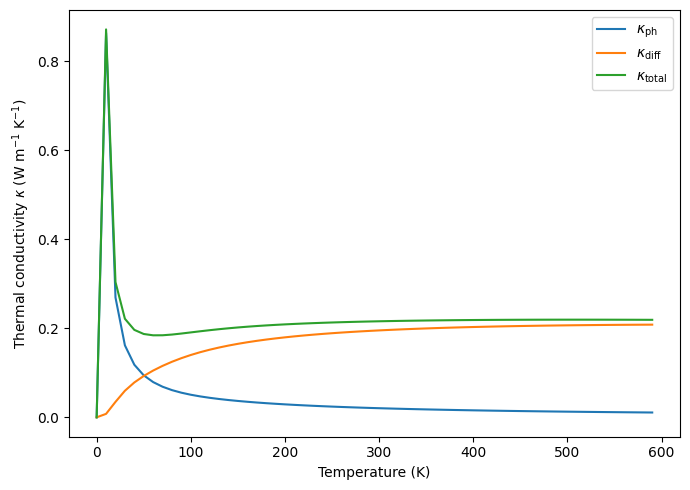

In [6]:
plt.figure(figsize=(7, 5))
plt.plot(df["Temperature"], df["kappa_ph"],   label=r"$\kappa_{\mathrm{ph}}$")
plt.plot(df["Temperature"], df["kappa_diff"], label=r"$\kappa_{\mathrm{diff}}$")
plt.plot(df["Temperature"], df["Kappa_total"],label=r"$\kappa_{\mathrm{total}}$")

plt.xlabel("Temperature (K)")
plt.ylabel(r"Thermal conductivity $\kappa$ (W m$^{-1}$ K$^{-1}$)")
plt.legend()
plt.tight_layout()

plt.savefig("kappa_vs_T.png")

plt.show()